# Renovate Scope & Dependency Analysis
This notebook analyzes the `DEPENDENCY_SCOPE_REPORT.md` to audit the "Signal Purity" of the OS.
It parses the distribution of Core OS Runtime, Tooling, and Quarantine items.

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

# File path
report_path = 'DEPENDENCY_SCOPE_REPORT.md'

totals = {}
samples = []

try:
    with open(report_path, 'r', encoding='utf-8') as f:
        content = f.read()

    # Extract Totals
    totals_match = re.search(r'## Totals\n([\s\S]*?)\n##', content)
    if totals_match:
        for line in totals_match.group(1).strip().split('\n'):
            if line.strip():
                # Handle potential variation in format
                parts = line.strip().replace('- ', '').split(': ')
                if len(parts) == 2:
                    totals[parts[0]] = int(parts[1])

    # Extract Samples
    samples_match = re.search(r'## Top Evidence Samples\n([\s\S]*)', content)
    if samples_match:
        for line in samples_match.group(1).strip().split('\n'):
            if line.strip():
                # Format: - Name -> Category (local=X; total=Y; wiring=Z)
                match = re.match(r'- (.*?) -> (.*?) \(local=(\d+); total=(\d+); wiring=(.*?)\)', line.strip())
                if match:
                    samples.append({
                        'Component': match.group(1),
                        'Category': match.group(2),
                        'Local_Count': int(match.group(3)),
                        'Total_Count': int(match.group(4)),
                        'Wiring_Status': match.group(5)
                    })

    print(f"Loaded {len(samples)} sample records.")
    print("Totals from Report:", totals)

except FileNotFoundError:
    print(f"File {report_path} not found. Please ensure it exists in the workspace.")

Loaded 20 sample records.
Totals from Report: {'CORE_OS_RUNTIME': 16, 'CORE_OS_TOOLING': 5, 'GEN2_APPS': 6, 'QUARANTINE': 140}


C:\Users\bsval\AppData\Local\Temp\ipykernel_39464\3494460593.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Count', data=df_totals, palette='viridis')


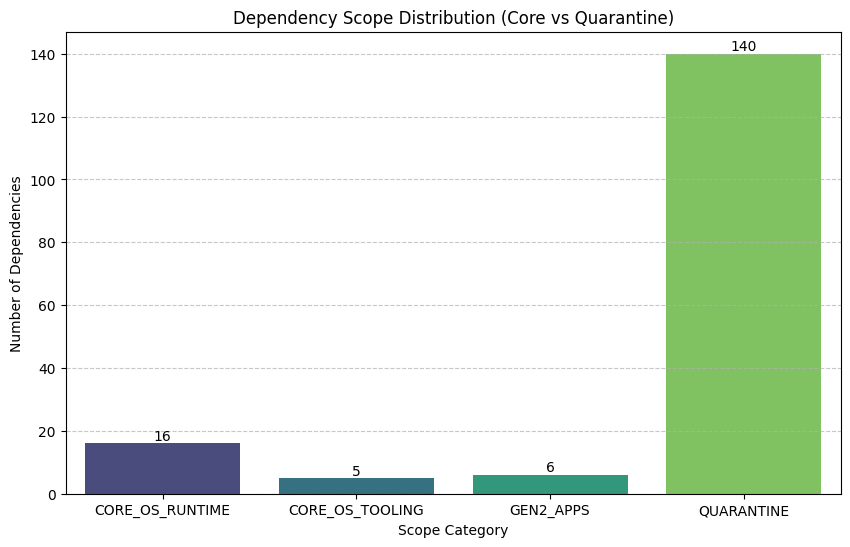

In [2]:
if totals:
    df_totals = pd.DataFrame(list(totals.items()), columns=['Category', 'Count'])
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Category', y='Count', data=df_totals, palette='viridis')
    plt.title('Dependency Scope Distribution (Core vs Quarantine)')
    plt.ylabel('Number of Dependencies')
    plt.xlabel('Scope Category')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Annotate bars
    for index, row in df_totals.iterrows():
        plt.text(index, row['Count'], str(row['Count']), color='black', ha="center", va="bottom")
        
    plt.show()
else:
    print("No total data loaded to visualize.")

Top 5 Evidence Samples:
                   Component        Category  Local_Count  Total_Count      Wiring_Status
                           . CORE_OS_TOOLING            4            6               none
                         .ai      QUARANTINE            0            0 kernel-gateway-ref
         .ci_artifacts_local      QUARANTINE            0            0               none
                     BS_PACS      QUARANTINE            2            3               none
CONSOLIDATED_20250915_062012      QUARANTINE            2            3               none


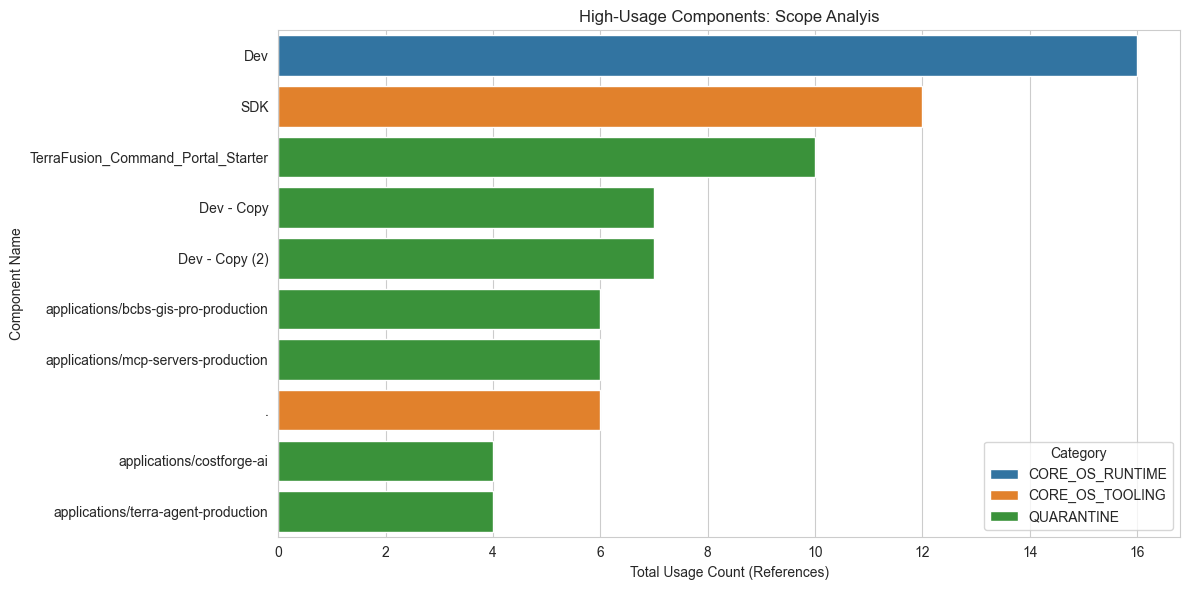

In [3]:
if samples:
    df_samples = pd.DataFrame(samples)
    print("Top 5 Evidence Samples:")
    # Using print to ensure output in basic runtimes, though display() is preferred in interactive NB
    print(df_samples.head(5).to_string(index=False))

    # Prepare data for plotting (Top 10 by Total Count)
    plot_df = df_samples.sort_values('Total_Count', ascending=False).head(10)

    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")
    
    # Bar chart of Usage
    chart = sns.barplot(x='Total_Count', y='Component', data=plot_df, hue='Category', dodge=False)
    
    plt.title('High-Usage Components: Scope Analyis')
    plt.xlabel('Total Usage Count (References)')
    plt.ylabel('Component Name')
    plt.tight_layout()
    plt.show()
else:
    print("No sample data available.")


# 📊 Governance Burn-Down Status (Increment 8.4.4)

## Tranche Execution Summary
Following the "Ratchet Governance" protocol, we have successfully executed four deterministic promotion tranches to reduce technical debt in the `QUARANTINE` scope.

| Tranche | Scope Target | Count Reduction | Baseline Hash | Status |
| :--- | :--- | :--- | :--- | :--- |
| **8.4.1** | Application Modules | 123 -> 103 (-20) | `434...d06` | ✅ Complete |
| **8.4.2** | Legacy Tools | 103 -> 101 (-2) | `5c6...eea` | ✅ Complete |
| **8.4.3** | Workspaces (Batch 1) | 101 -> 81 (-20) | `d86...db9` | ✅ Complete |
| **8.4.4** | Workspaces (Batch 2) | 81 -> **61** (-20) | `061...b35` | ✅ Complete |

## 🔍 Quarantine Remainder Report (61 Items)

The remaining 61 items in quarantine represent the final technical debt to be classified. These generally fall into higher-risk categories requiring deeper analysis or specific "Infrastructure" scope handling.

### High-Risk Candidates (Tranche 5)
*   **Infrastructure**: `infrastructure/monitoring`, `infrastructure/database`, `infrastructure/marketplace-enhanced`
*   **Deployment**: `deployment/production`, `deployment/benton-county`
*   **Packages**: `packages/commercial`, `packages/government-edition`
*   **Core Systems**: `os-kernel`, `terrafusion-cos`

### Analysis for Next Steps
The next Increment (8.4.5) should focus on separating **Infrastructure** components (which may need a `RUNTIM` or `INFRA` scope) from purely development artifacts.


In [4]:

# Analysis of Remaining 61 Quarantine Items
import json

# Manual injection of remaining items for analysis (sourced from dependency-scope-quarantine.json)
quarantine_remainder = [
    "_CLEAN_BUILD_ZONE", "_pre_restore_safety_20260108_144218", ".ai", ".ci_artifacts_local", ".venv",
    "agents/terrafusion-phd-systems-agent", "ai-workspace-companion",
    "applications/bcbs-gis-pro-production", "applications/bcbs-webhub-production", 
    "applications/bs-income-valuation-production", "applications/costforge-ai", 
    "applications/mcp-servers-production", "applications/terra-agent-production",
    "apps", "BS_PACS", "consciousness-isolated-workspace", "CONSOLIDATED_20250915_062012",
    "costforge-ai", "costforge-ai-workspace",
    "deployment/advanced", "deployment/benton-county", "deployment/installers", 
    "deployment/production", "deployment/web-demo", 
    "Dev - Copy", "Dev - Copy (2)", "distributions",
    "infrastructure/cache", "infrastructure/database", "infrastructure/marketplace-enhanced",
    "infrastructure/marketplace-unified", "infrastructure/monitoring",
    "kubernetes",
    "marketplace/autonomous-research-engine", "marketplace/commercial", "marketplace/government-core",
    "marketplace/shock-and-awe",
    "monorepo-scaffolding", "os-kernel", "os-platform", "os-platform/ai-systems",
    "os-platform/consciousness", "os-platform/infrastructure", "os-platform/performance",
    "os-platform/specialized",
    "packages/commercial", "packages/government-edition", "packages/government-edition-enhanced-MARKED-FOR-REVIEW",
    "packages/shock-and-awe", 
    "pacs-quantum-ui", "TerraFusion_Command_Portal_Starter", "terrafusion-cos", 
    "terrafusion-native-shell", "terrafusion-ops-tools",
    "tools/speclock-tss", "tools/tdc", "tools/tf-designctl-node", "tools/tf-designctl-rust",
    "validation", "workspace-explorer", "workspaces/workspaces"
]

# Simple Classification Heuristic
categories = {
    "Infrastructure": [],
    "Deployment": [],
    "Applications/Packages": [],
    "Tools/Scripts": [],
    "Core/System": [],
    "Legacy/Backup": [],
    "Other": []
}

for item in quarantine_remainder:
    if "infrastructure" in item or "kubernetes" in item or "cache" in item or "database" in item:
        categories["Infrastructure"].append(item)
    elif "deployment" in item:
        categories["Deployment"].append(item)
    elif "applications" in item or "packages" in item or "marketplace" in item or "apps" in item:
        categories["Applications/Packages"].append(item)
    elif "tools" in item or "scripts" in item or "scaffolding" in item:
        categories["Tools/Scripts"].append(item)
    elif "os-" in item or "terrafusion-" in item or "core" in item or ".ai" in item or ".venv" in item:
        categories["Core/System"].append(item)
    elif "Copy" in item or "restore" in item or "CONSOLIDATED" in item or "Starter" in item:
        categories["Legacy/Backup"].append(item)
    else:
        categories["Other"].append(item)

# Print Distribution
print(f"Total Remaining Items: {len(quarantine_remainder)}")
print("-" * 40)
for cat, items in categories.items():
    print(f"{cat}: {len(items)}")
    # Start 3 to sample
    for i in items[:3]:
        print(f"  - {i}")
    if len(items) > 3:
        print(f"  ... (+{len(items)-3} more)")


Total Remaining Items: 61
----------------------------------------
Infrastructure: 7
  - infrastructure/cache
  - infrastructure/database
  - infrastructure/marketplace-enhanced
  ... (+4 more)
Deployment: 5
  - deployment/advanced
  - deployment/benton-county
  - deployment/installers
  ... (+2 more)
Applications/Packages: 15
  - applications/bcbs-gis-pro-production
  - applications/bcbs-webhub-production
  - applications/bs-income-valuation-production
  ... (+12 more)
Tools/Scripts: 6
  - monorepo-scaffolding
  - terrafusion-ops-tools
  - tools/speclock-tss
  ... (+3 more)
Core/System: 11
  - .ai
  - .venv
  - agents/terrafusion-phd-systems-agent
  ... (+8 more)
Legacy/Backup: 5
  - _pre_restore_safety_20260108_144218
  - CONSOLIDATED_20250915_062012
  - Dev - Copy
  ... (+2 more)
Other: 12
  - _CLEAN_BUILD_ZONE
  - .ci_artifacts_local
  - ai-workspace-companion
  ... (+9 more)
